# Fast Example: BVA

A quick demonstration of computing and visualizing burst variance analysis from [Torella et. al. 2011](https://doi.org/10.1016/j.bpj.2011.01.066).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf

Load the data

In [2]:
raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

## Make Burst Search

The BVA column is created by `smf.fretfactory.make_burst_search`, the default chuck size is set by the `nbva` 

In [3]:
dbg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, auto_threshold=True, tail_min=5e-4)
nbva = 5
dbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')), nbva=nbva)
gate = smf.make_geq_gate(dbs['NphDex_raw'], 30) * smf.make_geq_gate(dbs['NphAA_raw'], 30)

It is always good to check the selection is reasonable in ES plots.

(-0.1, 1.1)

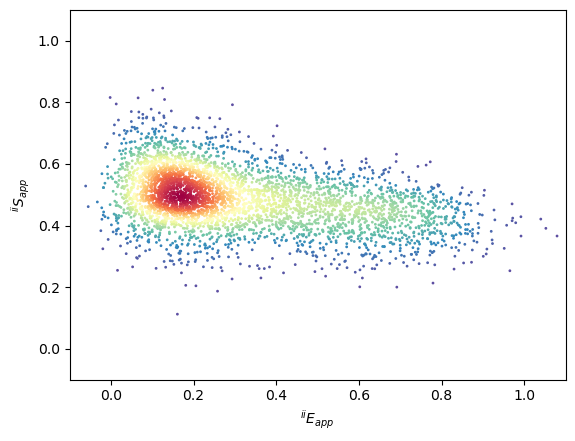

In [4]:
smf.plot.scatter(data, dbs['E_bg'], dbs['S_bg'], gate=gate, s=1.0, point_func=smf.plot.density_kde, cmap='Spectral_r')
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

Now we can plot the BVA as the `BVA10` column (if nbva were for instance 5, then the column would be `BVA5`)
We compute the expected as static variance as sqrt{x(1-x)/n}$,
and we can plot the mean of an interval in `E_raw` with the `smf.plotscatter_meaninterval()` function.

Note the use of fully uncorrected proximity ratio, this is because the computation of expected variance is valid only between $[0,1]$

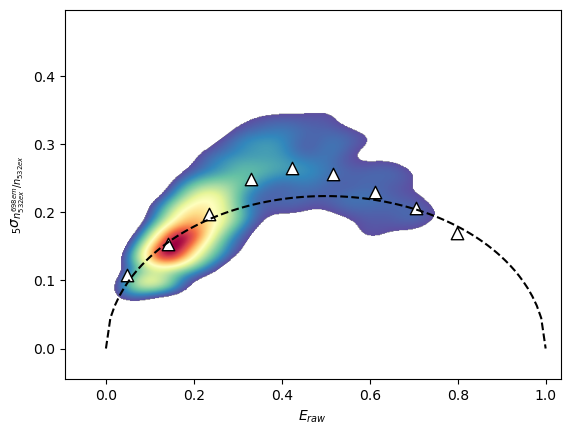

In [5]:
fig, ax = plt.subplots()
smf.plot.kdeplot(data, dbs['E_raw'], dbs['BVA5'], gate=gate, thresh=0.1, cmap='Spectral_r', ax=ax)
smf.plot.scatter_meaninterval(data, dbs['E_raw'], dbs['BVA5'], gate=gate, ax=ax, marker='^', c='w', ec='k', s=80)
x = np.linspace(0, 1, 100)
y_bva = np.sqrt(x*(1-x)/nbva)
ax.plot(x, y_bva, ls='--', c='k')

## Publication recomendations

### Citations

Of course, after we are done we should remember to print out the citations wtih `smf.print_citations()` 
(or get them with `smf.get_citations()` instead for a more detailed list)

In [6]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved
    excitation. Biophysical Journal 89, 3508–3522 (2005).
3. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
4. Torella, J. P., Holden, S. J., Santoso, Y., Hohlbein, J. & Kapanidis, A. N.
    Identifying molecular dynamics in single-molecule fret experiments with
    burst variance analysis. Biophysical J. 100, 1568–1577 (2011).


### Print Params

It is also recomended to get descriptions of the parameters used for the analysis.

All `Param`, `Column`, and `GateGroup` objects have a `.description` property.
Printing this will generate a yaml-like string that is good to add to your supplementary data, as it exactly describes the object.

Since we always used the `gate` as our gate, we can fold the gate into the description with the `.regate()` method.
You should select at a minimum the key Columns used in your anlalysis.
Also note that this is a full description, so a `Column` description will include the description of the `Param` on which it is based.

In [7]:
print(dbs['BVA5'].regate(gate).description)

Column: BurstOvlp, bva, 0ex1em, 0ex, 5
  Params:
    fuse: 0.0
    truthtable: [[False False]
                 [False  True]]
  Parents:
    bases:
      - Table: Bursts
        Params:
          func: smfbursts.bursttables.burstsearch_mwindowF_bg
          stream: 0ex
          m: 10
          F: 6.0
          c: -1.0
          fuse: 0.0
        Parents:
          bg:
            Table: BG
            Params:
              compute_stream: single_all
              func: smfbursts.backgroundtables.exp_mlefit
              tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
              auto_threshold: True
              F_bg: 2.0
            Parents:
              base:
                Table: Periods
                Params:
                  period: 60.0
                  start_at: time_min
                  stop_at: over
                  detdef: DetDef2ex2em  - Table: Bursts
        Params:
          func: smfbursts.bursttables.burstsearch_mwindowF_bg
          stream: 1ex1em
          m:

In this tutorial we used only one gate, if multiple gates are used, 
it is best to give all their descriptions separately.